# Multi-horizon Edge Handover Model (Transformer, leakage-safe)

Goal:
- Predict the best target cell **H steps ahead** (multi-horizon), where each timestep is **50 ms**.
- Avoid order leakage caused by neighbor lists being score-sorted (optimal at index 0).

Key design choices:
- **Leakage-safe data pipeline**: shuffle the neighbor axis *per sample* and track labels after shuffle.
- **No LSTM**: temporal encoder is a Transformer over the **time axis** (per cell, shared weights).
- **Multi-horizon output**: predicts `P(best_cell_at_t+h | history)` for `h=1..H`.

Outputs:
- Best model saved to `models/best_mh_transformer.keras`
- Cache saved to `dataset/mh_cache/`



In [ ]:
# --- Environment / paths ---tability gating
import os, sys, json, pickle, re, time
from pathlib import Path

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import top_k_accuracy_score

_ROOT = Path('../../').resolve()

PATHS = dict(
    raw_csv = _ROOT / 'dataset' / 'raw' / 'handover_dataset.csv',
    split   = _ROOT / 'dataset' / ,
    cache   = _ROOT / 'dataset' / 'mh_cache',
    models  = _ROOT / 'models',
    metrics = _ROOT / 'metrics' / 'experiment-mh-transformer',
)
for p in PATHS.values():
    if p.suffix == '':
        os.makedirs(str(p), exist_ok=True)

print('TF:', tf.__version__)
for k,v in PATHS.items():
    print(f'{k:>6}: {v}')


2026-05-30 11:26:37.901789: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-30 11:26:37.901827: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-30 11:26:37.902976: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-30 11:26:37.910908: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2026-05-30 11:26:39.024131: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TF: 2.15.1
raw_csv: /home/wassimmchichi/Downloads/Handover_projects/dataset/raw/handover_dataset.csv
 split: /home/wassimmchichi/Downloads/Handover_projects/dataset/processed/ue_split.json
 cache: /home/wassimmchichi/Downloads/Handover_projects/dataset/mh_cache
models: /home/wassimmchichi/Downloads/Handover_projects/models
metrics: /home/wassimmchichi/Downloads/Handover_projects/metrics/experiment-mh-transformer


In [2]:
# --- Hyperparameters ---
HP = dict(
    SEED=42,
    MEASUREMENT_INTERVAL_MS=50,

    # Data
    K=10,
    T=100,             # history window (25*50ms=1.25s)
    H=5,              # horizons (5*50ms=250ms)
    LEAD=0,           # lead steps before horizon-1 label (0 = label starts immediately after history)

    # Features
    USE_GLOBAL=True,

    # Model
    D_MODEL=96,
    N_HEADS=4,
    FF_DIM=192,
    N_LAYERS=3,
    DROPOUT=0.15,

    # Training
    BATCH=64,
    EPOCHS=60,
    LR=3e-4,
)

np.random.seed(HP['SEED']); tf.random.set_seed(HP['SEED'])
print('window_ms:', HP['T']*HP['MEASUREMENT_INTERVAL_MS'])
print('horizon_ms:', HP['H']*HP['MEASUREMENT_INTERVAL_MS'])


window_ms: 5000
horizon_ms: 250


In [3]:
# --- List parsers ---
_BRACKETS = re.compile(r'[\[\]]')

def parse_float_list(s, k, fill=0.0):
    if pd.isna(s):
        return np.full(k, fill, dtype=np.float32)
    cleaned = _BRACKETS.sub('', str(s)).strip()
    if not cleaned:
        return np.full(k, fill, dtype=np.float32)
    parts = re.split(r'[,;]', cleaned)
    out=[]
    for p in parts[:k]:
        p=p.strip()
        if p=='' or p.lower() in ('nan','none'):
            out.append(fill)
        else:
            try: out.append(float(p))
            except: out.append(fill)
    out += [fill]*(k-len(out))
    return np.asarray(out, dtype=np.float32)


def parse_int_list(s, k):
    if pd.isna(s):
        return [0]*k
    cleaned = _BRACKETS.sub('', str(s)).strip()
    if not cleaned:
        return [0]*k
    parts = re.split(r'[,;]', cleaned)
    out=[]
    for p in parts[:k]:
        p=p.strip()
        try: out.append(int(float(p)))
        except: out.append(0)
    out += [0]*(k-len(out))
    return out


In [4]:
# --- Build or load mh_cache ---
SEED = HP['SEED']
K = HP['K']; T = HP['T']; H = HP['H']; LEAD = HP['LEAD']

CACHE = PATHS['cache']
TRAIN_NPZ = CACHE/'train.npz'
VAL_NPZ   = CACHE/'val.npz'
TEST_NPZ  = CACHE/'test.npz'
SCALER_PKL= CACHE/'scaler.pkl'
META_JSON = CACHE/'meta.json'

meta_want = dict(K=K,T=T,H=H,LEAD=LEAD,USE_GLOBAL=HP['USE_GLOBAL'],label='optimal_cell_id')

if META_JSON.exists() and TRAIN_NPZ.exists() and VAL_NPZ.exists() and TEST_NPZ.exists() and SCALER_PKL.exists():
    meta = json.loads(META_JSON.read_text())
    if meta == meta_want:
        print('Loading mh_cache...')
        tr=np.load(TRAIN_NPZ); va=np.load(VAL_NPZ); te=np.load(TEST_NPZ)
        scaler = pickle.loads(SCALER_PKL.read_bytes())
        X_tr,M_tr,y_tr = tr['X'], tr['M'], tr['y']
        X_va,M_va,y_va = va['X'], va['M'], va['y']
        X_te,M_te,y_te = te['X'], te['M'], te['y']
        print('X_tr',X_tr.shape,'y_tr',y_tr.shape)
    else:
        print('Cache meta mismatch → rebuild')
        meta=None
else:
    meta=None

if meta is None:
    t0=time.time()
    df=pd.read_csv(PATHS['raw_csv'], low_memory=False)
    df['timestamp']=pd.to_datetime(df['timestamp'], format='mixed')
    df=df.sort_values(['ue_id','timestamp']).reset_index(drop=True)

    with open(PATHS['split']) as f:
        ue=json.load(f)
    ue_tr=set(ue['train_ues']); ue_va=set(ue['val_ues']); ue_te=set(ue['test_ues'])

    # Parse once (vectorized via apply)
    df['nb_ids']=df['nb_cell_ids'].apply(lambda x: parse_int_list(x,K))
    df['nb_r']=df['nb_rsrps'].apply(lambda x: parse_float_list(x,K,fill=0.0))
    df['nb_s']=df['nb_sinrs'].apply(lambda x: parse_float_list(x,K,fill=0.0))
    df['nb_l']=df['nb_loads'].apply(lambda x: parse_float_list(x,K,fill=0.0))

    nb_ids=np.asarray(df['nb_ids'].to_list(), dtype=np.int64)     # (N,K)
    nb_r=np.stack(df['nb_r'].to_numpy()).astype(np.float32)       # (N,K)
    nb_s=np.stack(df['nb_s'].to_numpy()).astype(np.float32)
    nb_l=np.stack(df['nb_l'].to_numpy()).astype(np.float32)

    # Global features (broadcasted to each cell)
    if HP['USE_GLOBAL']:
        sp=df['speed'].to_numpy(np.float32)
        dr=np.radians(df['direction'].to_numpy(np.float32))
        g=np.stack([
            sp,
            np.cos(dr),
            np.sin(dr),
            df['cell_load'].to_numpy(np.float32),
        ], axis=1)  # (N,4)
    else:
        g=None

    base = np.stack([nb_r,nb_s,nb_l], axis=2).astype(np.float32)  # (N,K,3)
    if g is not None:
        gk = np.repeat(g[:,None,:], K, axis=1).astype(np.float32) # (N,K,4)
        cell_feat = np.concatenate([base, gk], axis=2)            # (N,K,7)
    else:
        cell_feat = base                                          # (N,K,3)

    label_ids = df['optimal_cell_id'].to_numpy(np.int64)
    serving_ids = df['serving_cell_id'].to_numpy(np.int64)

    rng=np.random.default_rng(SEED)

    out = {s: {'X':[], 'M':[], 'y':[]} for s in ['train','val','test']}

    for ue_id, grp in df.groupby('ue_id', sort=False):
        ue_key=str(ue_id)
        if ue_key in ue_tr: split='train'
        elif ue_key in ue_va: split='val'
        elif ue_key in ue_te: split='test'
        else: continue

        idx=grp.index.to_numpy()
        n=len(idx)
        # Need room for future horizons
        if n < T + LEAD + H:
            continue

        for t in range(T, n - (LEAD + H) + 1):
            obs_rows = idx[t-T:t]            # last obs row = idx[t-1]
            anchor_row = idx[t-1]
            anchor_ids = nb_ids[anchor_row].tolist()

            # Consistent shuffle for the full window
            p = rng.permutation(K)

            Xw = cell_feat[obs_rows]         # (T,K,F)
            Xw = Xw[:, p, :]                 # (T,K,F)
            Xw = Xw.transpose(1,0,2)         # (K,T,F)

            Mw = (Xw[:, -1, 0] != 0.0).astype(np.float32)

            # Multi-horizon labels: best cell id at future rows, mapped into anchor_ids then through permutation
            y_h = np.zeros((H,), dtype=np.int32)
            for h in range(H):
                future_row = idx[t + LEAD + h]
                chosen_id = int(label_ids[future_row])
                try:
                    orig = anchor_ids.index(chosen_id)
                    y_h[h] = int(np.where(p == orig)[0][0])
                except ValueError:
                    # fallback: serving cell at future_row mapped to anchor
                    srv = int(serving_ids[future_row])
                    try:
                        orig = anchor_ids.index(srv)
                        y_h[h] = int(np.where(p == orig)[0][0])
                    except ValueError:
                        y_h[h] = 0

            out[split]['X'].append(Xw)
            out[split]['M'].append(Mw)
            out[split]['y'].append(y_h)

    def stack(split):
        X=np.asarray(out[split]['X'], np.float32)
        M=np.asarray(out[split]['M'], np.float32)
        y=np.asarray(out[split]['y'], np.int32)
        return X,M,y

    X_tr,M_tr,y_tr = stack('train')
    X_va,M_va,y_va = stack('val')
    X_te,M_te,y_te = stack('test')

    # Scale on train only (valid cells only)
    scaler=StandardScaler()
    valid = (M_tr==1.0)
    F = X_tr.shape[-1]
    if valid.sum()==0:
        scaler.fit(X_tr.reshape(-1,F))
        def scale(X):
            return scaler.transform(X.reshape(-1,F)).reshape(X.shape).astype(np.float32)
        X_trn,X_van,X_ten = scale(X_tr),scale(X_va),scale(X_te)
    else:
        scaler.fit(X_tr[valid].reshape(-1,F))
        def scale_masked(X,M):
            Xn=X.copy(); v=(M==1.0)
            if v.sum()>0:
                Xn[v]=scaler.transform(X[v].reshape(-1,F)).reshape(-1,T,F)
            return Xn.astype(np.float32)
        X_trn = scale_masked(X_tr,M_tr)
        X_van = scale_masked(X_va,M_va)
        X_ten = scale_masked(X_te,M_te)

    os.makedirs(str(CACHE), exist_ok=True)
    np.savez_compressed(TRAIN_NPZ, X=X_trn, M=M_tr, y=y_tr)
    np.savez_compressed(VAL_NPZ,   X=X_van, M=M_va, y=y_va)
    np.savez_compressed(TEST_NPZ,  X=X_ten, M=M_te, y=y_te)
    SCALER_PKL.write_bytes(pickle.dumps(scaler))
    META_JSON.write_text(json.dumps(meta_want, indent=2))

    print('built cache in',round(time.time()-t0,1),'s')
    print('train',X_trn.shape,'val',X_van.shape,'test',X_ten.shape)



FileNotFoundError: [Errno 2] No such file or directory: '/home/wassimmchichi/Downloads/Handover_projects/dataset/processed/ue_split.json'

In [ ]:
# --- tf.data ---
C=K
F=X_tr.shape[-1]

# one-hot: (N,H,K)
y_tr_oh = tf.one_hot(y_tr, depth=C).numpy().astype(np.float32)
y_va_oh = tf.one_hot(y_va, depth=C).numpy().astype(np.float32)
y_te_oh = tf.one_hot(y_te, depth=C).numpy().astype(np.float32)

AUTOTUNE=tf.data.AUTOTUNE

def make_ds(X,M,y,shuffle=False):
    with tf.device('/CPU:0'):
        ds=tf.data.Dataset.from_tensor_slices(({'cells':X,'mask':M}, y))
    if shuffle:
        ds=ds.shuffle(len(X), seed=HP['SEED'], reshuffle_each_iteration=True)
    return ds.batch(HP['BATCH']).prefetch(AUTOTUNE)


ds_tr = make_ds(X_tr, M_tr, y_tr_oh, shuffle=True)
ds_va = make_ds(X_va, M_va, y_va_oh)
ds_te = make_ds(X_te, M_te, y_te_oh)

print('batches train',len(ds_tr),'val',len(ds_va),'test',len(ds_te))


2026-05-30 02:42:40.124467: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-30 02:42:40.269338: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-30 02:42:40.272889: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

batches train 647 val 139 test 139


In [ ]:
# --- Loss (multi-horizon focal) ---

def temporal_focal_loss(gamma=2.0, alpha=0.25):
    def _loss(y_true, y_pred):
        y_pred = tf.clip_by_value(tf.cast(y_pred, tf.float32), 1e-7, 1.0-1e-7)
        y_true = tf.cast(y_true, tf.float32)
        ce = -y_true * tf.math.log(y_pred)                 # (B,H,K)
        p_t = tf.reduce_sum(y_true*y_pred, axis=-1, keepdims=True)  # (B,H,1)
        w = alpha * tf.pow(1.0 - p_t, gamma)              # (B,H,1)
        step_loss = tf.reduce_sum(w*ce, axis=-1)          # (B,H)
        return tf.reduce_mean(step_loss)                  # scalar
    return _loss

LOSS_FN = temporal_focal_loss(gamma=2.0, alpha=0.25)


In [ ]:
# --- Model: per-cell temporal Transformer + DeepSet pooling + horizon head ---

class MaskedGlobalAveragePooling(layers.Layer):
    def call(self, x, mask):
        # x: (B,C,D) mask: (B,C,1)
        summed = tf.reduce_sum(x * mask, axis=1)
        count  = tf.maximum(tf.reduce_sum(mask, axis=1), 1e-8)
        return summed / count


def transformer_encoder(x, *, num_heads, key_dim, ff_dim, dropout):
    # Pre-LN Transformer block
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)
    att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout)(x1, x1)
    att = layers.Dropout(dropout)(att)
    x2 = layers.Add()([x, att])

    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    ff = layers.Dense(ff_dim, activation='relu')(x3)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(x.shape[-1])(ff)
    return layers.Add()([x2, ff])


def build_model():
    C,T_,F_ = K,T,F
    H_ = H
    D = HP['D_MODEL']

    inp_cells = keras.Input((C,T_,F_), name='cells', dtype='float32')
    inp_mask  = keras.Input((C,), name='mask', dtype='float32')

    # (B*C, T, F)
    x = layers.Reshape((C*T_, F_))(inp_cells)
    x = layers.Reshape((C, T_, F_))(x)  # no-op but keeps intent
    x = tf.reshape(inp_cells, (-1, T_, F_))

    # project
    x = layers.Dense(D)(x)

    # learnable positional embedding
    pos = tf.range(start=0, limit=T_, delta=1)
    pos_emb = layers.Embedding(input_dim=T_, output_dim=D)(pos)  # (T,D)
    x = x + pos_emb

    # transformer stack
    key_dim = D // HP['N_HEADS']
    for _ in range(HP['N_LAYERS']):
        x = transformer_encoder(x, num_heads=HP['N_HEADS'], key_dim=key_dim, ff_dim=HP['FF_DIM'], dropout=HP['DROPOUT'])

    # pool time -> per-cell embedding
    x = layers.GlobalAveragePooling1D()(x)     # (B*C, D)
    phi = tf.reshape(x, (-1, C, D))            # (B, C, D)

    # masked set pooling
    mask_exp = layers.Reshape((C,1))(inp_mask)
    z = MaskedGlobalAveragePooling()(phi, mask_exp)        # (B,D)

    # horizon embedding + per-cell scoring
    h_ids = tf.range(H_)
    h_emb = layers.Embedding(input_dim=H_, output_dim=D)(h_ids)  # (H,D)

    # Broadcast to (B,C,H,D)
    phi4 = tf.expand_dims(phi, axis=2)
    phi4 = tf.tile(phi4, [1,1,H_,1])

    z4 = tf.reshape(z, (-1,1,1,D))
    z4 = tf.tile(z4, [1,C,H_,1])

    he4 = tf.reshape(h_emb, (1,1,H_,D))
    he4 = tf.tile(he4, [tf.shape(phi)[0], C, 1, 1])

    u = layers.Concatenate(axis=-1)([phi4, z4, he4])  # (B,C,H,3D)

    # scorer MLP
    u = layers.Dense(D, activation='relu')(u)
    u = layers.Dropout(HP['DROPOUT'])(u)
    logits = layers.Dense(1)(u)                # (B,C,H,1)
    logits = tf.squeeze(logits, axis=-1)       # (B,C,H)
    logits = tf.transpose(logits, perm=[0,2,1]) # (B,H,C)

    # masked softmax per horizon
    mask_h = tf.expand_dims(inp_mask, axis=1)   # (B,1,C)
    logits = logits + (1.0 - mask_h) * (-1e9)
    probs = layers.Softmax(dtype='float32', name='cell_probs_h')(logits)  # (B,H,C)

    m = keras.Model([inp_cells, inp_mask], probs, name='MH_Transformer_DeepSet')
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=HP['LR']),
        loss=LOSS_FN,
        metrics=[keras.metrics.CategoricalAccuracy(name='top1_acc')],
    )
    return m

model = build_model()
model.summary(line_length=110)


Model: "MH_Transformer_DeepSet"
______________________________________________________________________________________________________________
 Layer (type)                    Output Shape                     Param #    Connected to                     
 cells (InputLayer)              [(None, 10, 100, 7)]             0          []                               
                                                                                                              
 tf.reshape (TFOpLambda)         (None, 100, 7)                   0          ['cells[0][0]']                  
                                                                                                              
 dense (Dense)                   (None, 100, 96)                  768        ['tf.reshape[0][0]']             
                                                                                                              
 tf.__operators__.add (TFOpLamb  (None, 100, 96)                  0          ['d

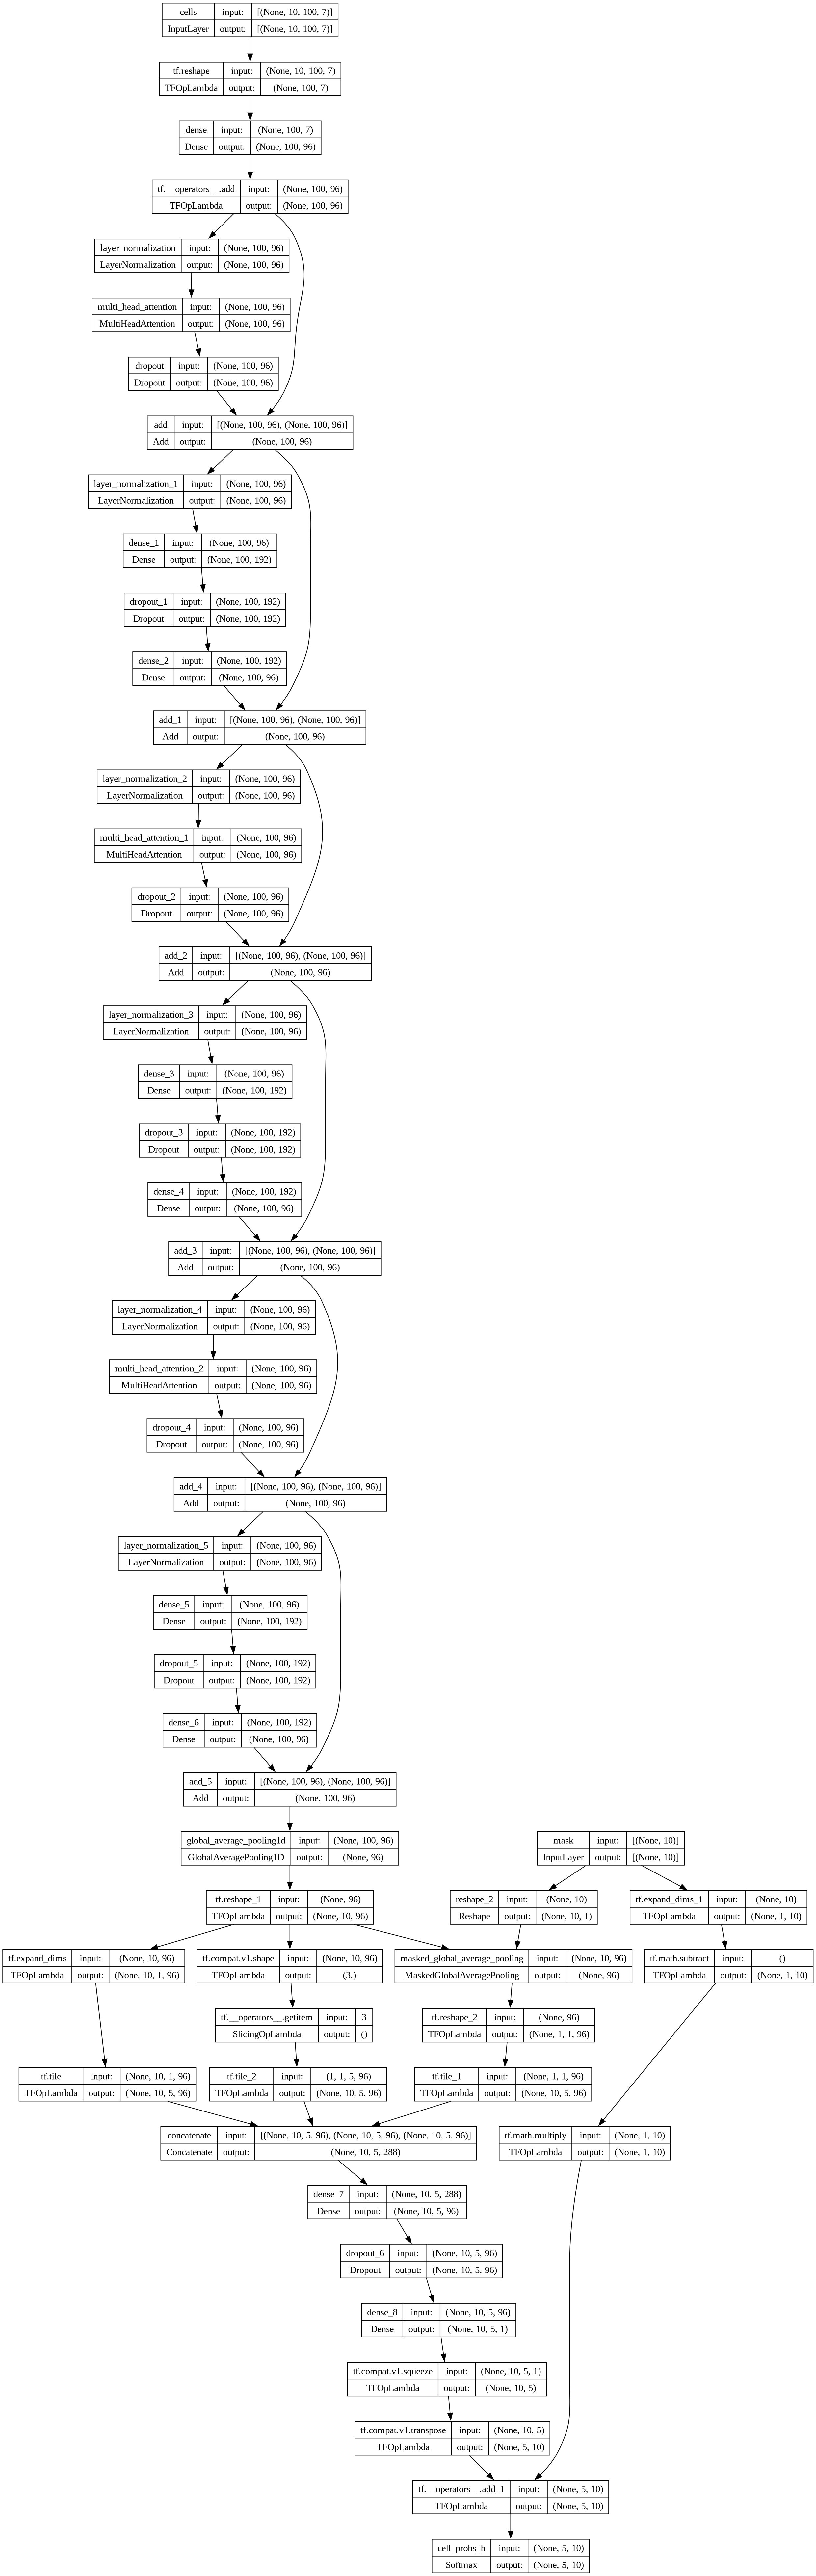

In [ ]:
_out = PATHS["metrics"] / "multihorozon_transformer_architecture.png"

tf.keras.utils.plot_model(
    model,
    to_file=str(_out),
    show_shapes=True,
    show_layer_names=True,
    dpi=150
)


In [ ]:
# --- Train ---
CKPT = PATHS['models'] / 'best_mh_transformer.keras'

callbacks=[
    keras.callbacks.ModelCheckpoint(str(CKPT), monitor='val_top1_acc', mode='max', save_best_only=True),
    keras.callbacks.EarlyStopping(monitor='val_top1_acc', mode='max', patience=8, restore_best_weights=True),
]

hist = model.fit(ds_tr, validation_data=ds_va, epochs=HP['EPOCHS'], callbacks=callbacks)


Epoch 1/60


2026-05-30 02:41:03.502849: W external/local_tsl/tsl/framework/bfc_allocator.cc:485] Allocator (GPU_0_bfc) ran out of memory trying to allocate 457.76MiB (rounded to 480000000)requested by op MH_Transformer_DeepSet/multi_head_attention/einsum/Einsum
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2026-05-30 02:41:03.502904: I external/local_tsl/tsl/framework/bfc_allocator.cc:1039] BFCAllocator dump for GPU_0_bfc
2026-05-30 02:41:03.502926: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (256): 	Total Chunks: 67, Chunks in use: 67. 16.8KiB allocated for chunks. 16.8KiB in use in bin. 317B client-requested in use in bin.
2026-05-30 02:41:03.502940: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (512): 	Total Chunks: 99, Chunks in use: 99. 52.0KiB allocated for chunks. 52.0KiB in use in bin. 40.5KiB clien

ResourceExhaustedError: Graph execution error:

Detected at node MH_Transformer_DeepSet/multi_head_attention/einsum/Einsum defined at (most recent call last):
  File "/home/wassimmchichi/miniconda3/envs/tda-handover/lib/python3.10/runpy.py", line 196, in _run_module_as_main

  File "/home/wassimmchichi/miniconda3/envs/tda-handover/lib/python3.10/runpy.py", line 86, in _run_code

  File "/home/wassimmchichi/miniconda3/envs/tda-handover/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/wassimmchichi/miniconda3/envs/tda-handover/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/wassimmchichi/miniconda3/envs/tda-handover/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/home/wassimmchichi/miniconda3/envs/tda-handover/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/home/wassimmchichi/miniconda3/envs/tda-handover/lib/python3

In [ ]:
# --- Evaluate: per-horizon top-1/top-k ---
probs = model.predict(ds_te, verbose=0)   # (N,H,K)

y_true = y_te

ALL_LABELS = list(range(K))

for h in range(H):
    top1 = float((probs[:,h,:].argmax(axis=1) == y_true[:,h]).mean())
    top3 = float(top_k_accuracy_score(y_true[:,h], probs[:,h,:], k=3, labels=ALL_LABELS))
    print(f'h={h+1} ({(h+1)*HP["MEASUREMENT_INTERVAL_MS"]}ms): top1={top1:.4f} top3={top3:.4f}')


h=1 (50ms): top1=0.6521 top3=0.9136
h=2 (100ms): top1=0.5733 top3=0.8560
h=3 (150ms): top1=0.5306 top3=0.8222
h=4 (200ms): top1=0.5051 top3=0.7991
h=5 (250ms): top1=0.4840 top3=0.7815


## Notes / Next steps

- If you want the production decision to arrive ~150–250 ms earlier, choose `H` (horizon steps) accordingly.
- For a deployable controller, combine the horizon output with hysteresis/TTT gating (see `src/production/temporal_deepset_decision.py`).
- For explainability on ray-tracing fine-tuning, a transformer makes it easier to analyze time attention and feature occlusions.
